# Logistic Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
dataset = pd.read_csv('/content/protein.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
dataset

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147
...,...,...,...,...,...,...,...,...,...,...
45725,3.762,8037.12,2777.68,0.34560,64.3390,1.105797e+06,112.7460,3384.21,84,36.8036
45726,6.521,7978.76,2508.57,0.31440,75.8654,1.116725e+06,102.2770,3974.52,54,36.0470
45727,10.356,7726.65,2489.58,0.32220,70.9903,1.076560e+06,103.6780,3290.46,46,37.4718
45728,9.791,8878.93,3055.78,0.34416,94.0314,1.242266e+06,115.1950,3421.79,41,35.6045


In [ ]:
X

array([[1.72840e+01, 1.35583e+04, 4.30535e+03, ..., 2.15359e+02,
        4.28787e+03, 1.02000e+02],
       [6.02100e+00, 6.19196e+03, 1.62316e+03, ..., 8.72024e+01,
        3.32891e+03, 3.90000e+01],
       [9.27500e+00, 7.72598e+03, 1.72628e+03, ..., 8.17913e+01,
        2.98104e+03, 2.90000e+01],
       ...,
       [1.03560e+01, 7.72665e+03, 2.48958e+03, ..., 1.03678e+02,
        3.29046e+03, 4.60000e+01],
       [9.79100e+00, 8.87893e+03, 3.05578e+03, ..., 1.15195e+02,
        3.42179e+03, 4.10000e+01],
       [1.88270e+01, 1.27324e+04, 4.44436e+03, ..., 2.29459e+02,
        4.62685e+03, 1.41000e+02]])

In [ ]:
y

array([27.0302, 38.5468, 38.8119, ..., 37.4718, 35.6045, 29.8118])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,
                                                    random_state = 0)

In [ ]:
print(y_test)

[37.5904 30.382  44.4937 ... 21.1112 42.0062 35.365 ]


In [ ]:
X_train[0:5]

array([[1.83760000e+01, 1.31050000e+04, 6.05293000e+03, 4.61870000e-01,
        1.10541000e+02, 1.79509708e+06, 2.10128000e+02, 5.03564000e+03,
        4.20000000e+01],
       [5.17700000e+00, 6.41680000e+03, 1.40747000e+03, 2.19340000e-01,
        5.56879000e+01, 8.99770495e+05, 7.23555000e+01, 3.00084000e+03,
        2.40000000e+01],
       [3.61300000e+00, 2.11188000e+04, 6.64604000e+03, 3.14690000e-01,
        2.63792000e+02, 2.96347149e+06, 3.02261000e+02, 5.61597000e+03,
        6.90000000e+01],
       [6.30000000e-01, 9.32825000e+03, 2.50839000e+03, 2.68900000e-01,
        9.45896000e+01, 1.27909996e+06, 1.55497000e+02, 4.09967000e+03,
        7.90000000e+01],
       [8.34800000e+00, 5.87617000e+03, 1.91075000e+03, 3.25160000e-01,
        5.48898000e+01, 8.12113028e+05, 7.94903000e+01, 3.12203000e+03,
        1.00000000e+01]])

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train[0:5]

array([[ 1.73657918,  0.79459471,  2.06707967,  2.53431225,  0.12709186,
         0.75449772,  0.92206604,  0.51618252, -0.49513162],
       [-0.42044176, -0.84987578, -1.09670657, -1.31906408, -0.86099996,
        -0.82946758, -1.0451912 , -0.48711339, -0.81427563],
       [-0.67603543,  2.76499894,  2.47101669,  0.19588019,  2.88766621,
         2.82152505,  2.23763562,  0.802325  , -0.01641559],
       [-1.16352641, -0.13401896, -0.34692602, -0.5316426 , -0.16024737,
        -0.15837759,  0.14198852,  0.05468514,  0.16088664],
       [ 0.09777276, -0.98280393, -0.75394819,  0.36223012, -0.87537647,
        -0.98454661, -0.9433132 , -0.42735842, -1.06249876]])

In [ ]:
print(X_test)

[[-1.02265573 -0.55606578 -0.70440187 ... -0.52185772 -0.20501901
  -0.77881519]
 [ 2.01112992  0.96333968  1.03652983 ...  1.23533361  0.2595354
   1.08285825]
 [ 0.51727975 -1.49021904 -1.21892083 ... -1.36850978 -1.28126442
  -0.70789429]
 ...
 [-0.86707698  2.26481259  2.09082104 ...  2.51442028  0.87910564
   4.29202864]
 [-0.83455579 -1.03207019 -0.71093313 ... -0.97954337 -0.71123278
  -0.81427563]
 [ 0.88302055 -0.14809046  0.15284141 ...  0.03816571 -0.10903335
   0.42683999]]


In [ ]:
from sklearn.linear_model import LinearRegression
classifier = LinearRegression()
classifier.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(classifier.predict(sc.transform([[30,87000,0,0,0,0,0,0,0]])))

[73.92565637]


In [ ]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1),
                      y_test.reshape(len(y_test),1)),1))

[[38.3167861  37.5904    ]
 [29.30301045 30.382     ]
 [42.27200334 44.4937    ]
 ...
 [20.6912966  21.1112    ]
 [40.217904   42.0062    ]
 [35.13597984 35.365     ]]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
y_pred = classifier.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Absolute Error: 1.6301927466527621
R-squared: 0.8391028092879214


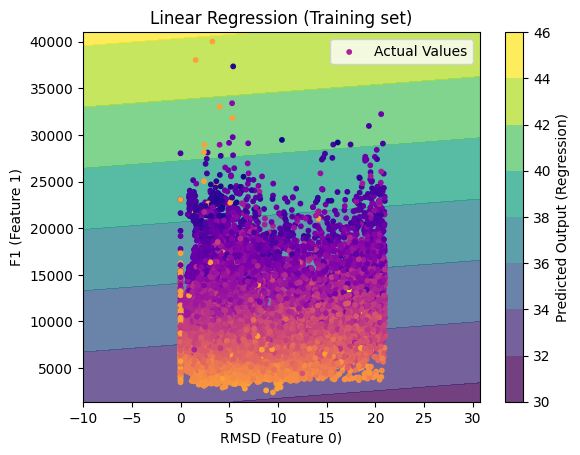

In [ ]:
from matplotlib.colors import ListedColormap, Normalize
import matplotlib.cm as cm

X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))


all_features_meshgrid = np.zeros((X1.size, X_set.shape[1]))
all_features_meshgrid[:, 0] = X1.ravel()
all_features_meshgrid[:, 1] = X2.ravel()

for i in range(2, X_set.shape[1]):
    all_features_meshgrid[:, i] = np.mean(X_set[:, i])

X_grid_scaled = sc.transform(all_features_meshgrid)

Z = classifier.predict(X_grid_scaled).reshape(X1.shape)

contour_cmap = 'viridis'
contour_norm = Normalize(vmin=Z.min(), vmax=Z.max())
plt.contourf(X1, X2, Z, alpha = 0.75, cmap = contour_cmap, norm=contour_norm)
plt.colorbar(label='Predicted Output (Regression)', ax=plt.gca())

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

scatter_cmap = cm.plasma
scatter_norm = Normalize(vmin=y_set.min(), vmax=y_set.max())
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=scatter_cmap, norm=scatter_norm, label='Actual Values', s=10)

plt.title('Linear Regression (Training set)')
plt.xlabel('RMSD (Feature 0)')
plt.ylabel('F1 (Feature 1)')
plt.legend()
plt.show()

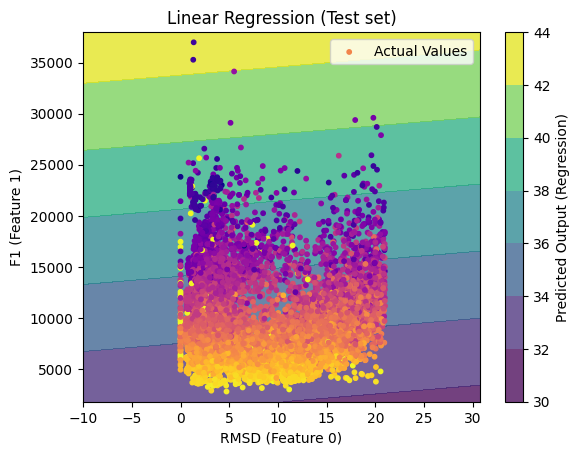

In [ ]:
from matplotlib.colors import ListedColormap, Normalize
import matplotlib.cm as cm
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))

all_features_meshgrid = np.zeros((X1.size, X_set.shape[1]))
all_features_meshgrid[:, 0] = X1.ravel()
all_features_meshgrid[:, 1] = X2.ravel()

for i in range(2, X_set.shape[1]):
    all_features_meshgrid[:, i] = np.mean(X_set[:, i])

X_grid_scaled = sc.transform(all_features_meshgrid)

Z = classifier.predict(X_grid_scaled).reshape(X1.shape)

contour_cmap = 'viridis'
contour_norm = Normalize(vmin=Z.min(), vmax=Z.max())
plt.contourf(X1, X2, Z, alpha = 0.75, cmap = contour_cmap, norm=contour_norm)
plt.colorbar(label='Predicted Output (Regression)', ax=plt.gca())

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

scatter_cmap = cm.plasma
scatter_norm = Normalize(vmin=y_set.min(), vmax=y_set.max())
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=scatter_cmap, norm=scatter_norm, label='Actual Values', s=10)

plt.title('Linear Regression (Test set)')
plt.xlabel('RMSD (Feature 0)')
plt.ylabel('F1 (Feature 1)')
plt.legend()
plt.show()